# Notebook 4 — Exploratory Data Analysis (EDA)

## Objective

This notebook performs Exploratory Data Analysis (EDA) on the training dataset.

The main goals are to:

- Understand the structure and quality of the training data.
- Analyze numerical and categorical features.
- Identify missing values and potential data quality issues.
- Examine feature distributions and possible outliers.
- Analyze the target variable `late`.
- Investigate relationships between features and late deliveries.
- Explore temporal and geographical patterns.
- Identify insights that will guide Feature Engineering in Notebook 5.

## Input

- `train.parquet`

## Outputs

- EDA analysis and statistics.
- Visualizations saved under `reports/figures/`.
- Key findings that will guide the next stage of the pipeline.

## Data Leakage Prevention

The Exploratory Data Analysis in this notebook is performed using the training split only.

The validation and test datasets are not used for exploratory analysis or decision-making.

## EDA Workflow

The analysis will follow these steps:

1. Import required libraries.
2. Load the training artifact.
3. Inspect the dataset structure.
4. Analyze data types and feature categories.
5. Check memory usage.
6. Analyze missing values.
7. Analyze numerical features.
8. Analyze categorical features.
9. Analyze the target variable.
10. Investigate relationships between features and `late`.
11. Analyze temporal patterns.
12. Analyze geographical patterns.
13. Document key findings.
14. Identify implications for Feature Engineering.

## 1. Environment Setup

In this section, we import the libraries required for the exploratory analysis.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Load Training Data


In [12]:
from pathlib import Path

project_root = Path.cwd().parent

print("Project root:", project_root)

train_path = project_root / "data" / "train.parquet"

print("Training data path:")
print(train_path)

print("\nFile exists:", train_path.exists())

Project root: c:\Users\user\Desktop\MLOps-Olist
Training data path:
c:\Users\user\Desktop\MLOps-Olist\data\train.parquet

File exists: True


In [13]:
df = pd.read_parquet(train_path)

print("Training data loaded successfully.")
print("Shape:", df.shape)
df.head()

Training data loaded successfully.
Shape: (67533, 29)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,item_count,total_item_price,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,unique_product_count,unique_seller_count,unique_category_count,avg_latitude,avg_longitude,late
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,3.0,134.97,...,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,1.0,1.0,1.0,-20.585751,-47.863693,1
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,1.0,29.90,...,32ea3bdedab835c3aa6cb68ce66565ef,4106,sao paulo,SP,1.0,1.0,1.0,-23.581451,-46.635029,0
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,1.0,21.90,...,2f64e403852e6893ae37485d5fcacdaf,98280,panambi,RS,1.0,1.0,1.0,-28.293541,-53.502238,0
3,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25,1.0,21.50,...,b8b8726af116a5cfb35b0315ecef9172,22770,rio de janeiro,RJ,1.0,1.0,1.0,-22.936911,-43.360973,0
4,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,1.0,36.49,...,61db744d2f835035a5625b59350c6b63,90040,porto alegre,RS,1.0,1.0,1.0,-30.041161,-51.213661,0


## 6. Basic Dataset Overview


In [14]:
print("Number of columns:", df.shape[1])

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

Number of columns: 29

Column names:
01. order_id
02. customer_id
03. order_status
04. order_purchase_timestamp
05. order_approved_at
06. order_delivered_carrier_date
07. order_delivered_customer_date
08. order_estimated_delivery_date
09. item_count
10. total_item_price
11. total_freight_value
12. avg_item_price
13. payment_count
14. total_payment_value
15. max_payment_installments
16. review_count
17. avg_review_score
18. min_review_score
19. max_review_score
20. customer_unique_id
21. customer_zip_code_prefix
22. customer_city
23. customer_state
24. unique_product_count
25. unique_seller_count
26. unique_category_count
27. avg_latitude
28. avg_longitude
29. late


### Data Types

In [15]:
dtype_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null": df.notna().sum().values,
    "missing": df.isna().sum().values,
    "unique_values": df.nunique(dropna=True).values
})

dtype_summary

,column,dtype,non_null,missing,unique_values
0,order_id,object,67533,0,67533
1,customer_id,object,67533,0,67533
2,order_status,object,67533,0,2
3,order_purchase_timestamp,datetime64[ns],67533,0,67155
4,order_approved_at,datetime64[ns],67519,14,63153
5,order_delivered_carrier_date,datetime64[ns],67532,1,63242
6,order_delivered_customer_date,datetime64[ns],67533,0,66958
7,order_estimated_delivery_date,datetime64[ns],67533,0,356
8,item_count,float64,67533,0,17
9,total_item_price,float64,67533,0,5799


### Dataset Information

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67533 entries, 0 to 67532
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       67533 non-null  object        
 1   customer_id                    67533 non-null  object        
 2   order_status                   67533 non-null  object        
 3   order_purchase_timestamp       67533 non-null  datetime64[ns]
 4   order_approved_at              67519 non-null  datetime64[ns]
 5   order_delivered_carrier_date   67532 non-null  datetime64[ns]
 6   order_delivered_customer_date  67533 non-null  datetime64[ns]
 7   order_estimated_delivery_date  67533 non-null  datetime64[ns]
 8   item_count                     67533 non-null  float64       
 9   total_item_price               67533 non-null  float64       
 10  total_freight_value            67533 non-null  float64       
 11  avg_item_price 

### Descriptive Statistics

In [17]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,67533,2017-10-20 23:51:27.394370304,2016-09-15 12:16:38,2017-07-22 14:42:47,2017-11-18 22:53:19,2018-01-31 16:03:47,2018-04-15 20:07:56,NaN
order_approved_at,67519,2017-10-21 11:01:37.489151232,2016-09-15 12:16:38,2017-07-22 22:30:10,2017-11-19 14:55:29,2018-02-01 02:52:44,2018-04-24 18:04:50,NaN
order_delivered_carrier_date,67532,2017-10-24 11:06:29.486228992,2016-10-08 10:34:01,2017-07-26 09:27:46.750000128,2017-11-22 17:35:53.500000,2018-02-05 13:15:49.500000,2018-05-08 14:04:00,NaN
order_delivered_customer_date,67533,2017-11-03 19:39:07.293263872,2016-10-11 13:46:32,2017-08-02 20:23:07,2017-11-30 15:49:01,2018-02-16 16:53:18,2018-09-19 23:24:07,NaN
order_estimated_delivery_date,67533,2017-11-14 14:11:33.101150464,2016-10-04 00:00:00,2017-08-15 00:00:00,2017-12-11 00:00:00,2018-03-01 00:00:00,2018-08-03 00:00:00,NaN
item_count,67533.0,1.142079,1.0,1.0,1.0,1.0,21.0,0.541635
total_item_price,67533.0,135.884499,2.29,45.9,85.0,149.9,13440.0,205.187627
total_freight_value,67533.0,22.244256,0.0,14.1,16.79,23.7,1002.29,19.999582
avg_item_price,67533.0,124.234649,1.514286,41.0,78.97,139.9,6735.0,185.653751
payment_count,67532.0,1.047622,1.0,1.0,1.0,1.0,26.0,0.397212


## 7. Feature Classification

In [18]:
# Define feature groups based on the dataset structure

target_col = "late"

id_cols = [
    "order_id",
    "customer_id",
    "customer_unique_id"
]

datetime_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

categorical_cols = [
    "order_status",
    "customer_city",
    "customer_state"
]

numerical_cols = [
    "item_count",
    "total_item_price",
    "total_freight_value",
    "avg_item_price",
    "payment_count",
    "total_payment_value",
    "max_payment_installments",
    "review_count",
    "avg_review_score",
    "min_review_score",
    "max_review_score",
    "customer_zip_code_prefix",
    "unique_product_count",
    "unique_seller_count",
    "unique_category_count",
    "avg_latitude",
    "avg_longitude"
]

print("ID columns:", len(id_cols))
print("Datetime columns:", len(datetime_cols))
print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))
print("Target column:", target_col)

ID columns: 3
Datetime columns: 5
Categorical columns: 3
Numerical columns: 17
Target column: late


### Classification Validation

In [19]:
classified_cols = (
    id_cols
    + datetime_cols
    + categorical_cols
    + numerical_cols
    + [target_col]
)

print("Total dataset columns:", len(df.columns))
print("Total classified columns:", len(classified_cols))
print("Unique classified columns:", len(set(classified_cols)))

missing_from_classification = set(df.columns) - set(classified_cols)
extra_in_classification = set(classified_cols) - set(df.columns)

print("\nColumns missing from classification:")
print(missing_from_classification)

print("\nColumns not present in dataset:")
print(extra_in_classification)

Total dataset columns: 29
Total classified columns: 29
Unique classified columns: 29

Columns missing from classification:
set()

Columns not present in dataset:
set()


### Feature Classification Table

In [20]:
feature_classification = []

for col in df.columns:
    if col in id_cols:
        feature_type = "ID"
    elif col in datetime_cols:
        feature_type = "Datetime"
    elif col in categorical_cols:
        feature_type = "Categorical"
    elif col in numerical_cols:
        feature_type = "Numerical"
    elif col == target_col:
        feature_type = "Target"
    else:
        feature_type = "Unknown"

    feature_classification.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "feature_type": feature_type
    })

feature_classification = pd.DataFrame(feature_classification)

feature_classification

,column,dtype,feature_type
0,order_id,object,ID
1,customer_id,object,ID
2,order_status,object,Categorical
3,order_purchase_timestamp,datetime64[ns],Datetime
4,order_approved_at,datetime64[ns],Datetime
5,order_delivered_carrier_date,datetime64[ns],Datetime
6,order_delivered_customer_date,datetime64[ns],Datetime
7,order_estimated_delivery_date,datetime64[ns],Datetime
8,item_count,float64,Numerical
9,total_item_price,float64,Numerical


## 8. Missing Values Analysis

In [21]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100
})

missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_percentage", ascending=False)
)

missing_summary

,missing_count,missing_percentage
max_review_score,515,0.762590
review_count,515,0.762590
avg_review_score,515,0.762590
min_review_score,515,0.762590
avg_latitude,181,0.268017
avg_longitude,181,0.268017
order_approved_at,14,0.020731
payment_count,1,0.001481
order_delivered_carrier_date,1,0.001481
total_payment_value,1,0.001481


### Missing Values by Feature


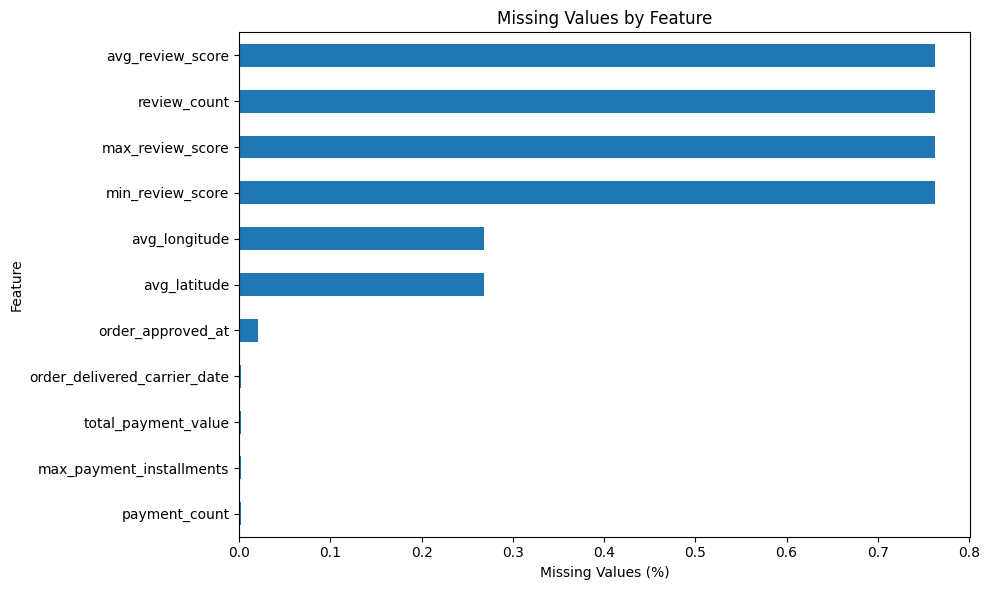

In [22]:
plt.figure(figsize=(10, 6))

missing_summary["missing_percentage"].sort_values().plot(
    kind="barh"
)

plt.title("Missing Values by Feature")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Save EDA Visualization


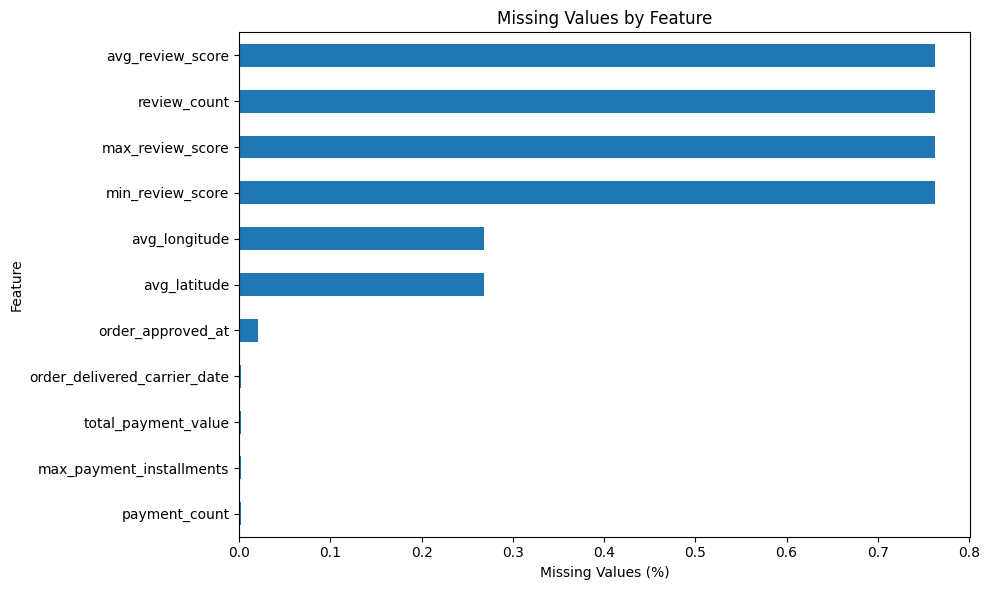

Saved to: c:\Users\user\Desktop\MLOps-Olist\reports\figures\missing_values.png


In [23]:
figures_path = project_root / "reports" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

missing_plot_path = figures_path / "missing_values.png"

plt.figure(figsize=(10, 6))

missing_summary["missing_percentage"].sort_values().plot(
    kind="barh"
)

plt.title("Missing Values by Feature")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig(missing_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved to:", missing_plot_path)

### Missingness Patterns


In [24]:
review_cols = [
    "review_count",
    "avg_review_score",
    "min_review_score",
    "max_review_score"
]

review_missing = df[review_cols].isna().all(axis=1)

print("Rows with all review information missing:", review_missing.sum())
print(
    "Percentage:",
    f"{review_missing.mean() * 100:.3f}%"
)

Rows with all review information missing: 515
Percentage: 0.763%


### Review Missingness by Order Status


In [25]:
review_status = pd.crosstab(
    df["order_status"],
    review_missing,
    normalize="index"
) * 100

review_status.columns = [
    "Review information present (%)",
    "Review information missing (%)"
]

review_status

,Review information present (%),Review information missing (%)
order_status,,
canceled,100.000000,0.000000
delivered,99.237342,0.762658


### Missing Geographic Coordinates


In [26]:
geo_cols = [
    "avg_latitude",
    "avg_longitude"
]

geo_missing = df[geo_cols].isna().all(axis=1)

print("Rows with both latitude and longitude missing:", geo_missing.sum())
print(
    "Percentage:",
    f"{geo_missing.mean() * 100:.3f}%"
)

Rows with both latitude and longitude missing: 181
Percentage: 0.268%


### Geographic Missingness by Customer State


In [28]:
geo_missing_by_state = (
    df.assign(geo_missing=geo_missing)
      .groupby("customer_state")["geo_missing"]
      .agg(["sum", "count"])
)

geo_missing_by_state["missing_percentage"] = (
    geo_missing_by_state["sum"]
    / geo_missing_by_state["count"]
    * 100
)

geo_missing_by_state = geo_missing_by_state.sort_values(
    "missing_percentage",
    ascending=False
)

geo_missing_by_state

,sum,count,missing_percentage
customer_state,,,
DF,109,1404,7.763533
RO,2,185,1.081081
PI,2,348,0.574713
PB,2,370,0.540541
TO,1,197,0.507614
MA,2,548,0.364964
ES,5,1445,0.346021
CE,3,948,0.316456
MT,2,640,0.312500


### Low-Frequency Missing Values


In [29]:
low_missing_cols = [
    "order_approved_at",
    "order_delivered_carrier_date",
    "payment_count",
    "total_payment_value",
    "max_payment_installments"
]

low_missing_mask = df[low_missing_cols].isna().any(axis=1)

low_missing_records = df.loc[
    low_missing_mask,
    ["order_id", "order_status"] + low_missing_cols
]

print("Rows with at least one low-frequency missing value:",
      low_missing_records.shape[0])

low_missing_records

Rows with at least one low-frequency missing value: 16


,order_id,order_status,order_approved_at,order_delivered_carrier_date,payment_count,total_payment_value,max_payment_installments
0,bfbd0f9bdef84302105ad712db648a6c,delivered,2016-09-15 12:16:38,2016-11-07 17:11:53,NaN,NaN,NaN
477,c1d4211b3dae76144deccd6c74144a88,delivered,NaT,2017-01-25 14:56:50,1.0,54.51,1.0
495,7002a78c79c519ac54022d4f8a65e6e8,delivered,NaT,2017-01-27 11:08:05,1.0,60.42,1.0
2118,12a95a3c06dbaec84bcfb0e2da5d228a,delivered,NaT,2017-02-22 11:23:11,1.0,95.76,1.0
2125,3c0b8706b065f9919d0505d3b3343881,delivered,NaT,2017-02-22 11:31:30,1.0,157.19,1.0
2130,2eecb0d85f281280f79fa00f9cec1a95,delivered,NaT,2017-02-22 11:42:51,1.0,154.23,1.0
2148,d77031d6a3c8a52f019764e68f211c69,delivered,NaT,2017-02-23 07:23:36,1.0,39.95,1.0
2155,8a9adc69528e1001fc68dd0aaebbb54a,delivered,NaT,2017-02-23 09:01:52,1.0,396.86,1.0
2157,7013bcfc1c97fe719a7b5e05e61c12db,delivered,NaT,2017-02-22 16:25:25,1.0,65.52,1.0
2166,e04abd8149ef81b95221e88f6ed9ab6a,delivered,NaT,2017-02-23 12:04:47,1.0,349.01,1.0


### Missing Values Summary


In [30]:
print("Total rows:", len(df))
print("Total columns:", len(df.columns))
print("Rows containing at least one missing value:", df.isna().any(axis=1).sum())
print("Columns containing missing values:", df.isna().any().sum())

Total rows: 67533
Total columns: 29
Rows containing at least one missing value: 711
Columns containing missing values: 11


## Target Variable Analysis


In [31]:
target_counts = df["late"].value_counts().sort_index()

target_percentages = (
    df["late"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages
})

target_summary

,count,percentage
late,,
0,61436,90.971821
1,6097,9.028179


### Target Class Distribution


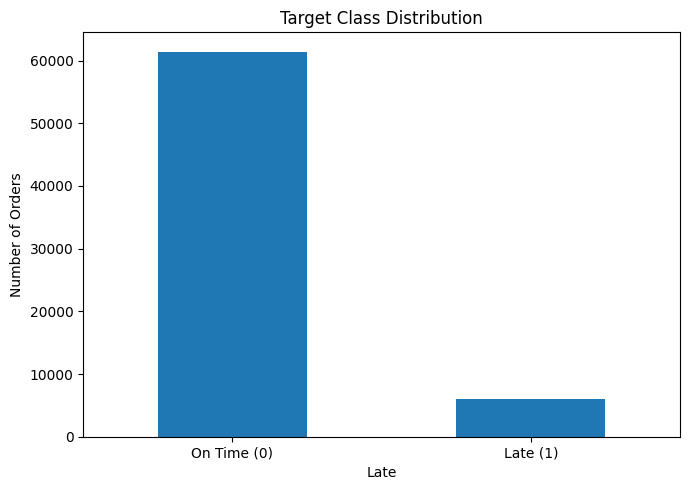

In [32]:
ax = target_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

ax.set_title("Target Class Distribution")
ax.set_xlabel("Late")
ax.set_ylabel("Number of Orders")
ax.set_xticklabels(["On Time (0)", "Late (1)"], rotation=0)

plt.tight_layout()
plt.show()

### Class Imbalance

In [33]:
class_0_count = (df["late"] == 0).sum()
class_1_count = (df["late"] == 1).sum()

imbalance_ratio = class_0_count / class_1_count

print(f"Class 0 count: {class_0_count:,}")
print(f"Class 1 count: {class_1_count:,}")
print(f"Imbalance ratio (0:1): {imbalance_ratio:.2f}:1")

Class 0 count: 61,436
Class 1 count: 6,097
Imbalance ratio (0:1): 10.08:1


## Numerical Features vs Target


In [34]:
numeric_features = [
    col for col in df.select_dtypes(include=np.number).columns
    if col != "late"
]

numeric_by_target = (
    df.groupby("late")[numeric_features]
    .agg(["mean", "median", "std"])
)

numeric_by_target

item_count                  total_item_price                     \
           mean median       std             mean median         std   
late                                                                   
0      1.144834    1.0  0.544545       134.506741  84.99  203.737309   
1      1.114319    1.0  0.510603       149.767376  89.99  218.801051   

     total_freight_value                   avg_item_price  ...  \
                    mean median        std           mean  ...   
late                                                       ...   
0              21.950632  16.60  19.604236     122.632952  ...   
1              25.202941  18.12  23.414034     140.374029  ...   

     unique_seller_count unique_category_count                  avg_latitude  \
                     std                  mean median       std         mean   
late                                                                           
0               0.119250              0.989550    1.0  0.157775   -21.242202   
1               0.051164              0.983106    1.0  0.142196   -20.007724   

                          avg_longitude                       
         median       std          mean     median       std  
late                                                          
0    -22.926257  5.573565    -46.285325 -46.639347  4.062615  
1    -22.813199  6.795485    -45.089263 -44.999202  4.483055  

[2 rows x 51 columns]

### Median Comparison


In [35]:
median_by_target = (
    df.groupby("late")[numeric_features]
    .median()
    .T
)

median_by_target.columns = [
    "on_time_median",
    "late_median"
]

median_by_target["difference"] = (
    median_by_target["late_median"]
    - median_by_target["on_time_median"]
)

median_by_target["absolute_difference"] = (
    median_by_target["difference"].abs()
)

median_by_target.sort_values(
    "absolute_difference",
    ascending=False
)

,on_time_median,late_median,difference,absolute_difference
customer_zip_code_prefix,25040.500000,29102.000000,4061.500000,4061.500000
total_payment_value,103.050000,113.855000,10.805000,10.805000
avg_item_price,77.000000,85.900000,8.900000,8.900000
total_item_price,84.990000,89.990000,5.000000,5.000000
min_review_score,5.000000,1.000000,-4.000000,4.000000
avg_review_score,5.000000,1.000000,-4.000000,4.000000
max_review_score,5.000000,1.000000,-4.000000,4.000000
avg_longitude,-46.639347,-44.999202,1.640146,1.640146
total_freight_value,16.600000,18.120000,1.520000,1.520000
avg_latitude,-22.926257,-22.813199,0.113057,0.113057


### Late Rate Across Price Ranges


In [36]:
price_bins = pd.qcut(
    df["total_item_price"],
    q=5,
    duplicates="drop"
)

price_late_rate = (
    df.groupby(price_bins, observed=True)["late"]
    .agg(["count", "mean"])
)

price_late_rate["late_percentage"] = (
    price_late_rate["mean"] * 100
)

price_late_rate

,count,mean,late_percentage
total_item_price,,,
"(2.289, 39.0]",13679,0.078734,7.873383
"(39.0, 65.9]",13369,0.086543,8.654350
"(65.9, 104.9]",13509,0.087941,8.794137
"(104.9, 175.0]",13477,0.098983,9.898345
"(175.0, 13440.0]",13499,0.099341,9.934069


### Late Rate Across Freight Value Ranges


In [37]:
freight_bins = pd.qcut(
    df["total_freight_value"],
    q=5,
    duplicates="drop"
)

freight_late_rate = (
    df.groupby(freight_bins, observed=True)["late"]
    .agg(["count", "mean"])
)

freight_late_rate["late_percentage"] = (
    freight_late_rate["mean"] * 100
)

freight_late_rate

,count,mean,late_percentage
total_freight_value,,,
"(-0.001, 13.0]",13518,0.049342,4.934162
"(13.0, 15.48]",13506,0.078706,7.870576
"(15.48, 18.02]",13534,0.095833,9.583272
"(18.02, 26.92]",13471,0.116027,11.602702
"(26.92, 1002.29]",13504,0.111597,11.159656


### Freight Value and Late Delivery Rate


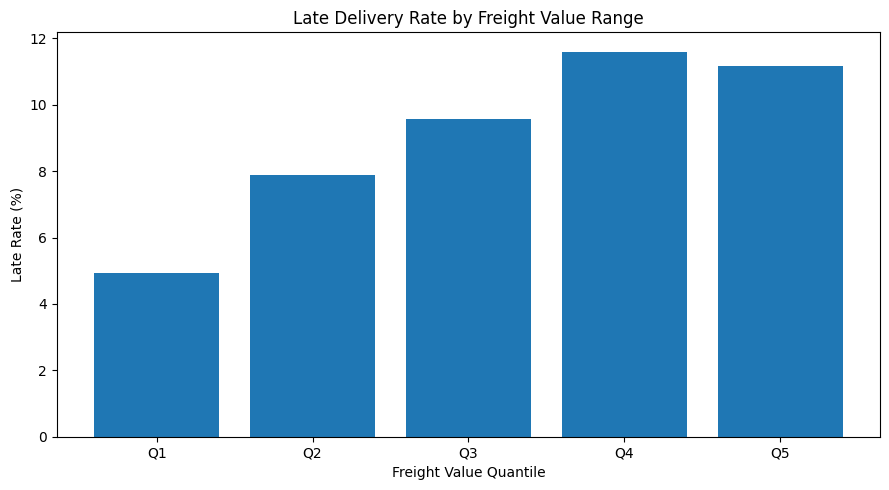

In [38]:
plt.figure(figsize=(9, 5))

plt.bar(
    range(len(freight_late_rate)),
    freight_late_rate["late_percentage"]
)

plt.title("Late Delivery Rate by Freight Value Range")
plt.xlabel("Freight Value Quantile")
plt.ylabel("Late Rate (%)")
plt.xticks(
    range(len(freight_late_rate)),
    [f"Q{i}" for i in range(1, len(freight_late_rate) + 1)]
)

plt.tight_layout()

plt.savefig(
    figures_path / "late_rate_by_freight_value.png",
    bbox_inches="tight"
)

plt.show()

### Item Price and Late Delivery Rate


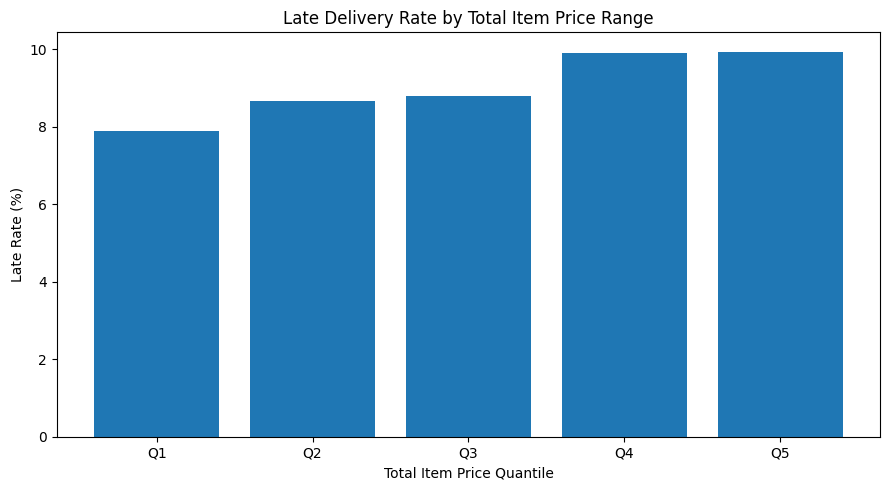

In [39]:
plt.figure(figsize=(9, 5))

plt.bar(
    range(len(price_late_rate)),
    price_late_rate["late_percentage"]
)

plt.title("Late Delivery Rate by Total Item Price Range")
plt.xlabel("Total Item Price Quantile")
plt.ylabel("Late Rate (%)")
plt.xticks(
    range(len(price_late_rate)),
    [f"Q{i}" for i in range(1, len(price_late_rate) + 1)]
)

plt.tight_layout()

plt.savefig(
    figures_path / "late_rate_by_total_item_price.png",
    bbox_inches="tight"
)

plt.show()

### Numerical Correlation with the Target


In [40]:
correlation_with_late = (
    df[numeric_features + ["late"]]
    .corr()["late"]
    .drop("late")
    .sort_values(key=abs, ascending=False)
)

correlation_with_late

avg_review_score           -0.405073
max_review_score           -0.405024
min_review_score           -0.404311
avg_longitude               0.083221
avg_latitude                0.061974
total_freight_value         0.046604
customer_zip_code_prefix    0.040410
avg_item_price              0.027386
unique_seller_count        -0.025872
total_payment_value         0.024756
unique_product_count       -0.021611
total_item_price            0.021315
max_payment_installments    0.017182
item_count                 -0.016146
unique_category_count      -0.011804
payment_count              -0.005894
review_count               -0.003862
Name: late, dtype: float64

### Correlation Excluding Review-Based Features


In [41]:
review_features = [
    "review_count",
    "avg_review_score",
    "min_review_score",
    "max_review_score"
]

numeric_features_pre_outcome = [
    col for col in numeric_features
    if col not in review_features
]

correlation_pre_outcome = (
    df[numeric_features_pre_outcome + ["late"]]
    .corr()["late"]
    .drop("late")
    .sort_values(key=abs, ascending=False)
)

correlation_pre_outcome

avg_longitude               0.083221
avg_latitude                0.061974
total_freight_value         0.046604
customer_zip_code_prefix    0.040410
avg_item_price              0.027386
unique_seller_count        -0.025872
total_payment_value         0.024756
unique_product_count       -0.021611
total_item_price            0.021315
max_payment_installments    0.017182
item_count                 -0.016146
unique_category_count      -0.011804
payment_count              -0.005894
Name: late, dtype: float64

### Numerical Correlations with Late Delivery


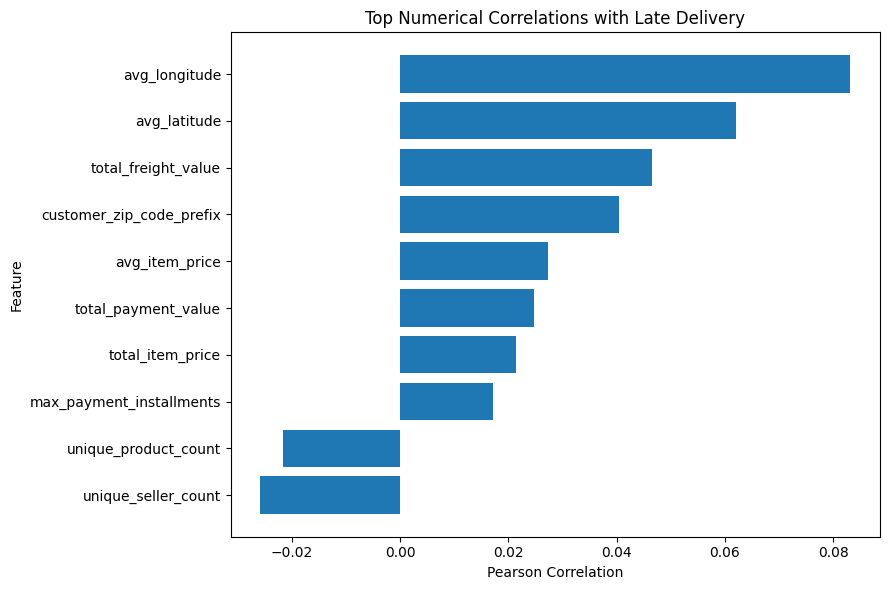

In [42]:
top_correlations = correlation_pre_outcome.head(10).sort_values()

plt.figure(figsize=(9, 6))

plt.barh(
    top_correlations.index,
    top_correlations.values
)

plt.title("Top Numerical Correlations with Late Delivery")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    figures_path / "top_numerical_correlations_with_late.png",
    bbox_inches="tight"
)

plt.show()

## Categorical Features Analysis


In [43]:
categorical_features = [
    "order_status",
    "customer_city",
    "customer_state"
]

categorical_summary = pd.DataFrame({
    "unique_values": [
        df[col].nunique(dropna=False)
        for col in categorical_features
    ],
    "missing_values": [
        df[col].isna().sum()
        for col in categorical_features
    ]
}, index=categorical_features)

categorical_summary

,unique_values,missing_values
order_status,2,0
customer_city,3747,0
customer_state,27,0


### Order Status Distribution


In [44]:
order_status_counts = df["order_status"].value_counts()

order_status_counts

order_status
delivered    67527
canceled         6
Name: count, dtype: int64

In [45]:
order_status_percentages = (
    df["order_status"]
    .value_counts(normalize=True)
    .mul(100)
)

order_status_percentages

order_status
delivered    99.991115
canceled      0.008885
Name: proportion, dtype: float64

### Customer State Distribution


In [46]:
state_counts = df["customer_state"].value_counts()

state_counts

customer_state
SP    27204
RJ     8967
MG     8130
RS     3912
PR     3461
SC     2577
BA     2307
ES     1445
GO     1409
DF     1404
PE     1117
CE      948
PA      718
MT      640
MA      548
MS      502
PB      370
RN      349
PI      348
AL      298
SE      246
TO      197
RO      185
AM      105
AC       66
AP       51
RR       29
Name: count, dtype: int64

In [47]:
state_percentages = (
    df["customer_state"]
    .value_counts(normalize=True)
    .mul(100)
)

state_percentages

customer_state
SP    40.282529
RJ    13.277953
MG    12.038559
RS     5.792724
PR     5.124902
SC     3.815912
BA     3.416108
ES     2.139695
GO     2.086387
DF     2.078984
PE     1.654006
CE     1.403758
PA     1.063184
MT     0.947685
MA     0.811455
MS     0.743340
PB     0.547880
RN     0.516784
PI     0.515304
AL     0.441266
SE     0.364266
TO     0.291709
RO     0.273940
AM     0.155480
AC     0.097730
AP     0.075519
RR     0.042942
Name: proportion, dtype: float64

### Late Delivery Rate by Customer State


In [48]:
state_late_rate = (
    df.groupby("customer_state")["late"]
    .agg(["count", "mean"])
)

state_late_rate["late_percentage"] = (
    state_late_rate["mean"] * 100
)

state_late_rate = state_late_rate.sort_values(
    "late_percentage",
    ascending=False
)

state_late_rate

,count,mean,late_percentage
customer_state,,,
AL,298,0.278523,27.852349
MA,548,0.215328,21.532847
CE,948,0.182489,18.248945
RR,29,0.172414,17.241379
SE,246,0.170732,17.073171
PI,348,0.166667,16.666667
RJ,8967,0.165830,16.583027
BA,2307,0.149978,14.997833
PA,718,0.133705,13.370474


Visualize State Late Rate

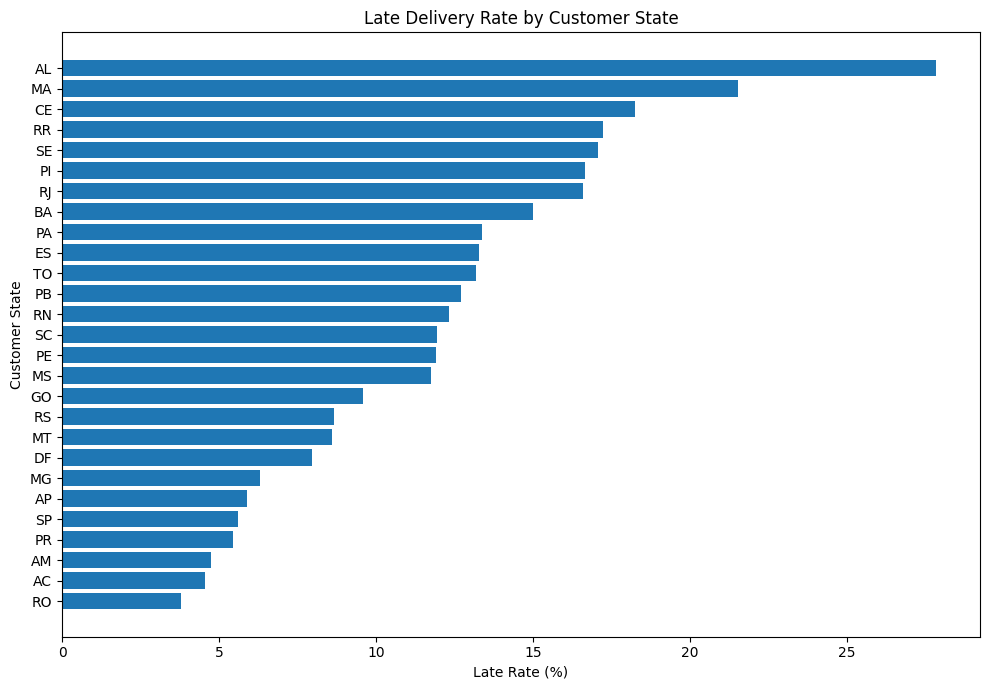

In [49]:
plt.figure(figsize=(10, 7))

plt.barh(
    state_late_rate.index,
    state_late_rate["late_percentage"]
)

plt.title("Late Delivery Rate by Customer State")
plt.xlabel("Late Rate (%)")
plt.ylabel("Customer State")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    figures_path / "late_rate_by_customer_state.png",
    bbox_inches="tight"
)

plt.show()

## Categorical Features and Target Relationship


In [50]:
categorical_features = [
    "order_status",
    "customer_city",
    "customer_state"
]

categorical_summary = pd.DataFrame({
    "unique_values": df[categorical_features].nunique(),
    "missing_values": df[categorical_features].isna().sum()
})

categorical_summary

,unique_values,missing_values
order_status,2,0
customer_city,3747,0
customer_state,27,0


### Order Status vs Late Delivery


In [51]:
order_status_late = (
    df.groupby("order_status")["late"]
    .agg(["count", "mean"])
)

order_status_late["late_percentage"] = (
    order_status_late["mean"] * 100
)

order_status_late = order_status_late.drop(columns="mean")

order_status_late

,count,late_percentage
order_status,,
canceled,6,16.666667
delivered,67527,9.027500


### Customer City and Late Delivery

In [52]:
city_late = (
    df.groupby("customer_city")["late"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "order_count",
        "sum": "late_count",
        "mean": "late_rate"
    })
)

city_late["late_percentage"] = city_late["late_rate"] * 100

city_late = city_late.sort_values(
    "order_count",
    ascending=False
)

city_late.head(20)

,order_count,late_count,late_rate,late_percentage
customer_city,,,,
sao paulo,9921,556,0.056043,5.604274
rio de janeiro,4780,706,0.147699,14.769874
belo horizonte,1869,129,0.069021,6.902087
brasilia,1395,112,0.080287,8.028674
curitiba,1020,55,0.053922,5.392157
porto alegre,975,136,0.139487,13.948718
campinas,967,110,0.113754,11.375388
salvador,823,161,0.195626,19.562576
guarulhos,724,44,0.060773,6.077348


In [53]:
city_late_50 = city_late[
    city_late["order_count"] >= 50
].copy()

city_late_50.sort_values(
    "late_percentage",
    ascending=False
).head(20)

,order_count,late_count,late_rate,late_percentage
customer_city,,,,
maceio,172,61,0.354651,35.465116
sao goncalo,282,81,0.287234,28.723404
sao joao de meriti,90,25,0.277778,27.777778
cabo frio,94,25,0.265957,26.595745
rio das ostras,97,23,0.237113,23.711340
sao luis,244,57,0.233607,23.360656
macae,155,36,0.232258,23.225806
sao jose,114,26,0.228070,22.807018
teresina,189,43,0.227513,22.751323


In [54]:
city_late_50.sort_values(
    "late_percentage",
    ascending=True
).head(20)

,order_count,late_count,late_rate,late_percentage
customer_city,,,,
franco da rocha,74,0,0.000000,0.000000
poa,56,0,0.000000,0.000000
braganca paulista,99,1,0.010101,1.010101
itatiba,71,1,0.014085,1.408451
vinhedo,65,1,0.015385,1.538462
taboao da serra,186,3,0.016129,1.612903
mogi mirim,60,1,0.016667,1.666667
vicosa,60,1,0.016667,1.666667
assis,59,1,0.016949,1.694915


## Temporal Analysis


In [55]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

date_summary = pd.DataFrame({
    "min_date": df[date_cols].min(),
    "max_date": df[date_cols].max(),
    "missing_values": df[date_cols].isna().sum()
})

date_summary

,min_date,max_date,missing_values
order_purchase_timestamp,2016-09-15 12:16:38,2018-04-15 20:07:56,0
order_approved_at,2016-09-15 12:16:38,2018-04-24 18:04:50,14
order_delivered_carrier_date,2016-10-08 10:34:01,2018-05-08 14:04:00,1
order_delivered_customer_date,2016-10-11 13:46:32,2018-09-19 23:24:07,0
order_estimated_delivery_date,2016-10-04 00:00:00,2018-08-03 00:00:00,0


Orders Over Time

In [56]:
monthly_orders = (
    df.set_index("order_purchase_timestamp")
      .resample("ME")
      .size()
)

monthly_orders.head()

order_purchase_timestamp
2016-09-30      1
2016-10-31    270
2016-11-30      0
2016-12-31      1
2017-01-31    750
Freq: ME, dtype: int64

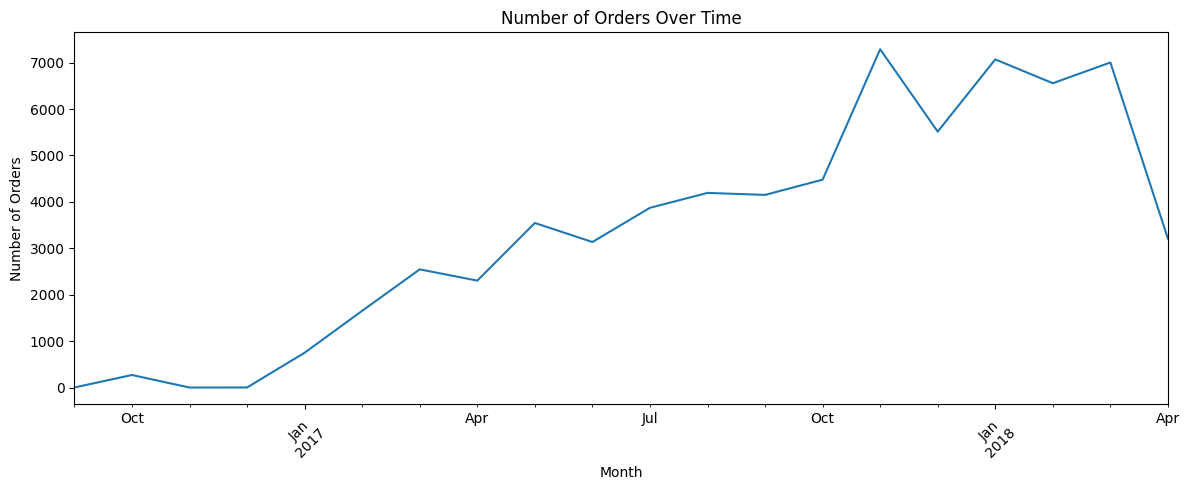

In [57]:
plt.figure(figsize=(12, 5))

monthly_orders.plot()

plt.title("Number of Orders Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    figures_path / "orders_over_time.png",
    bbox_inches="tight"
)

plt.show()

Late Rate by Month

In [58]:
monthly_late_rate = (
    df.set_index("order_purchase_timestamp")
      .resample("ME")["late"]
      .mean()
      .mul(100)
)

monthly_late_rate

order_purchase_timestamp
2016-09-30    100.000000
2016-10-31      1.111111
2016-11-30           NaN
2016-12-31      0.000000
2017-01-31      3.066667
2017-02-28      3.206292
2017-03-31      5.577376
2017-04-30      7.859314
2017-05-31      3.610719
2017-06-30      3.859649
2017-07-31      3.434917
2017-08-31      3.315049
2017-09-30      5.204819
2017-10-31      5.292541
2017-11-30     14.311196
2017-12-31      8.380192
2018-01-31      6.563870
2018-02-28     16.000610
2018-03-31     21.362273
2018-04-30      6.423449
Freq: ME, Name: late, dtype: float64

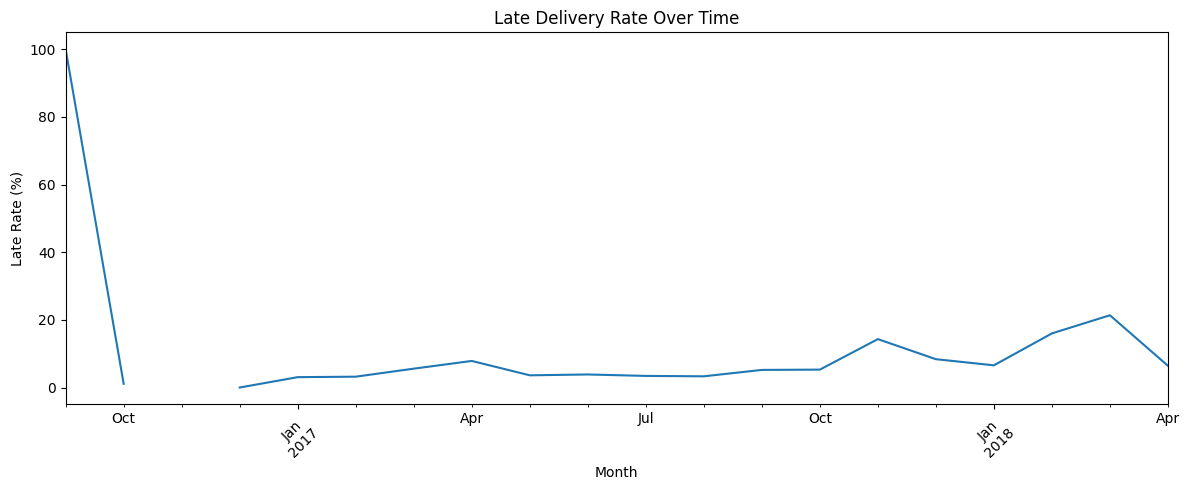

In [59]:
plt.figure(figsize=(12, 5))

monthly_late_rate.plot()

plt.title("Late Delivery Rate Over Time")
plt.xlabel("Month")
plt.ylabel("Late Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    figures_path / "late_rate_over_time.png",
    bbox_inches="tight"
)

plt.show()

### Late Delivery Rate by Day of Week


In [60]:

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_late_rate = (
    df.assign(
        purchase_weekday=df["order_purchase_timestamp"].dt.day_name()
    )
    .groupby("purchase_weekday")["late"]
    .agg(["count", "mean"])
    .reindex(weekday_order)
)

weekday_late_rate["late_percentage"] = (
    weekday_late_rate["mean"] * 100
)

weekday_late_rate = weekday_late_rate.drop(columns="mean")

weekday_late_rate

,count,late_percentage
purchase_weekday,,
Monday,10736,10.022355
Tuesday,10729,9.264610
Wednesday,10339,8.608183
Thursday,10005,8.285857
Friday,9885,9.468892
Saturday,7594,8.967606
Sunday,8245,8.380837


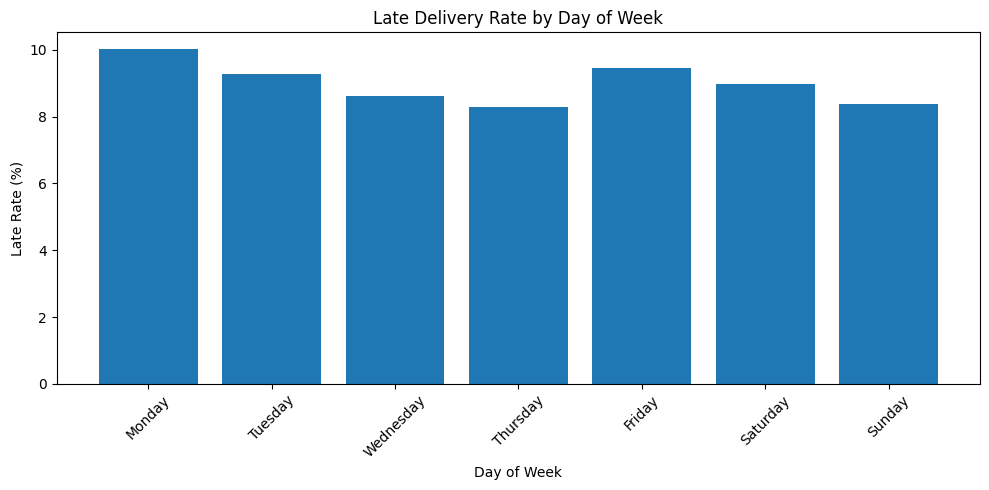

In [61]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_late_rate.index,
    weekday_late_rate["late_percentage"]
)

plt.title("Late Delivery Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Late Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    figures_path / "late_rate_by_weekday.png",
    bbox_inches="tight"
)

plt.show()

### Late Delivery Rate by Purchase Hour


In [62]:
hourly_late_rate = (
    df.assign(
        purchase_hour=df["order_purchase_timestamp"].dt.hour
    )
    .groupby("purchase_hour")["late"]
    .agg(["count", "mean"])
)

hourly_late_rate["late_percentage"] = (
    hourly_late_rate["mean"] * 100
)

hourly_late_rate = hourly_late_rate.drop(columns="mean")

hourly_late_rate

,count,late_percentage
purchase_hour,,
0,1662,9.687124
1,837,8.841099
2,370,7.837838
3,186,4.838710
4,136,7.352941
5,134,8.208955
6,318,8.176101
7,806,8.064516
8,1951,8.508457


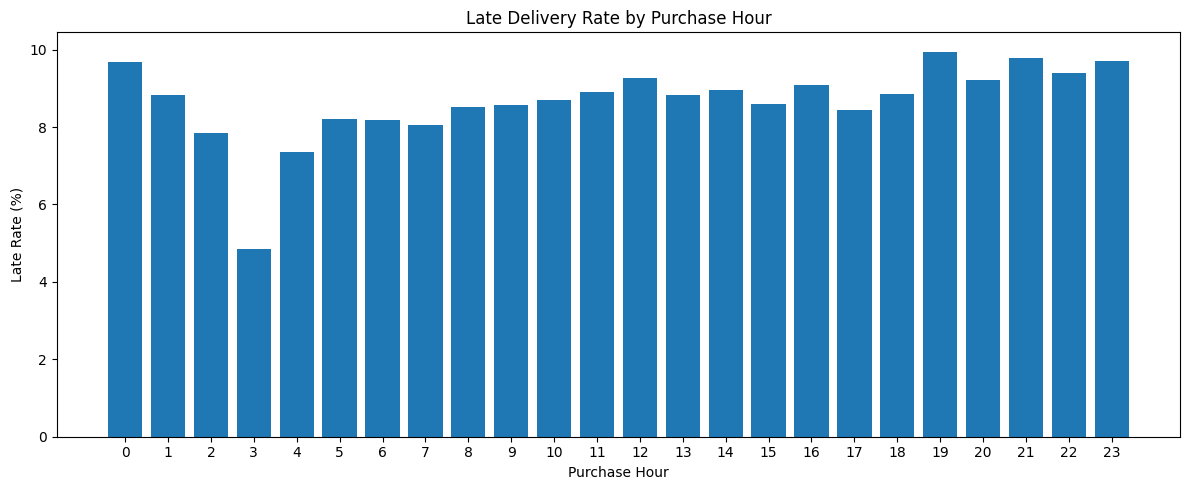

In [63]:
plt.figure(figsize=(12, 5))

plt.bar(
    hourly_late_rate.index,
    hourly_late_rate["late_percentage"]
)

plt.title("Late Delivery Rate by Purchase Hour")
plt.xlabel("Purchase Hour")
plt.ylabel("Late Rate (%)")
plt.xticks(range(24))
plt.tight_layout()

plt.savefig(
    figures_path / "late_rate_by_purchase_hour.png",
    bbox_inches="tight"
)

plt.show()

## Geographic Numerical Features


In [64]:

geo_features = [
    "customer_zip_code_prefix",
    "avg_latitude",
    "avg_longitude"
]

geo_by_late = (
    df.groupby("late")[geo_features]
    .agg(["mean", "median", "std"])
)

geo_by_late

customer_zip_code_prefix                        avg_latitude             \
                         mean   median           std         mean     median   
late                                                                           
0                35629.392213  25040.5  30057.913562   -21.242202 -22.926257   
1                39846.627194  29102.0  28071.916513   -20.007724 -22.813199   

               avg_longitude                       
           std          mean     median       std  
late                                               
0     5.573565    -46.285325 -46.639347  4.062615  
1     6.795485    -45.089263 -44.999202  4.483055

In [65]:
zip_bins = pd.qcut(
    df["customer_zip_code_prefix"],
    q=5,
    duplicates="drop"
)

zip_late_rate = (
    df.groupby(zip_bins, observed=True)["late"]
    .agg(["count", "mean"])
)

zip_late_rate["late_percentage"] = (
    zip_late_rate["mean"] * 100
)

zip_late_rate = zip_late_rate.drop(columns="mean")

zip_late_rate

,count,late_percentage
customer_zip_code_prefix,,
"(1003.999, 8790.0]",13508,5.285757
"(8790.0, 19696.0]",13505,5.960755
"(19696.0, 35162.0]",13539,13.893197
"(35162.0, 71926.0]",13478,11.388930
"(71926.0, 99980.0]",13503,8.605495


### EDA Conclusions

The dataset contains 67,533 observations and 29 columns, with `late` as the target variable. The target is imbalanced, with 9.03% late deliveries and 90.97% on-time deliveries, corresponding to an imbalance ratio of approximately 10.08:1. Therefore, accuracy alone should not be used as the primary evaluation metric during model development.

Missing values are limited to 711 rows and are concentrated mainly in review-related features (0.763%) and geographic coordinates (0.268%). Since the overall amount of missing data is small, these values can be handled during preprocessing without removing a substantial portion of the dataset.

Several numerical variables show differences between late and on-time orders. In particular, higher freight values and higher total item prices are associated with higher late-delivery rates. Geographic variables also show meaningful differences across Brazilian states and cities, even though their individual linear correlations with the target are relatively weak.

Temporal analysis reveals changes in late-delivery rates across months, with particularly high rates observed toward the beginning of 2018. Weekday and hourly patterns are less pronounced, although some variation is present.

Review-related variables have the strongest linear correlation with the target. However, review information may be generated after an order has been delivered. Consequently, these features must be carefully evaluated for temporal/data leakage before being used for predictive modeling.

Overall, the EDA indicates that delivery lateness is influenced by a combination of temporal, geographic, and order-related characteristics. These findings will guide feature preprocessing and model development in the subsequent notebooks.
